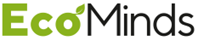

# Topic: Computer Vision for Environmental Safety
## Course: Machine Learning for Environmental Applications

##Ivan Komin

##Group: IP-44

# Workshop: Vegetation Health Assessment Using NDVI

This notebook computes and compares **current NDVI** against a **historical baseline** for a given Area of Interest (AOI) using satellite imagery.

**Output:**
- Current NDVI composite
- Historical NDVI composite
- Visual comparison map for vegetation condition assessment

The notebook is structured as a linear, reproducible pipeline with all configuration parameters defined upfront.

# 1. Configuration & Libraries

In [61]:
import folium
import ee
import matplotlib.pyplot as plt
import seaborn as sns
import IPython.display as disp
from branca.element import Figure
import numpy as np

## 1a. Mark the Area of Interest (AOI)
Define a polygon of your area of interest using GeoJSON file. Copy the GeoJSON file by marking the AOI by hand in the website: https://geojson.io/

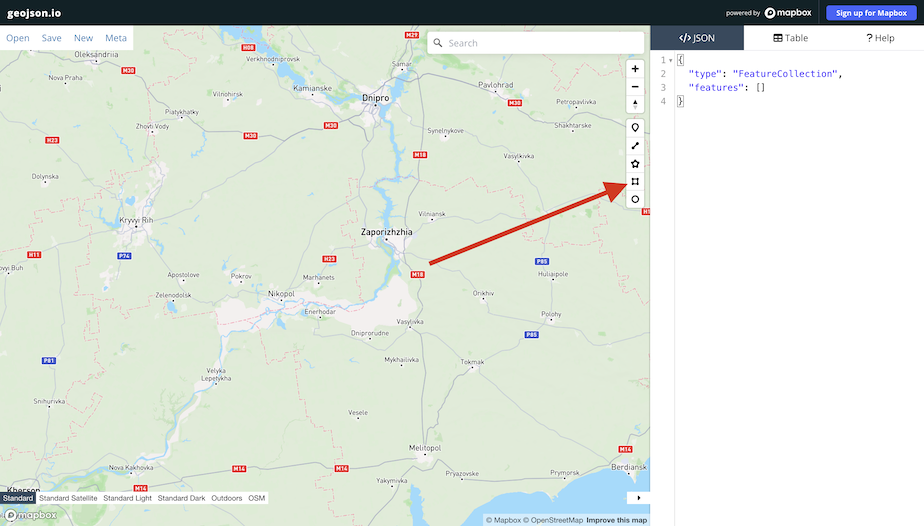

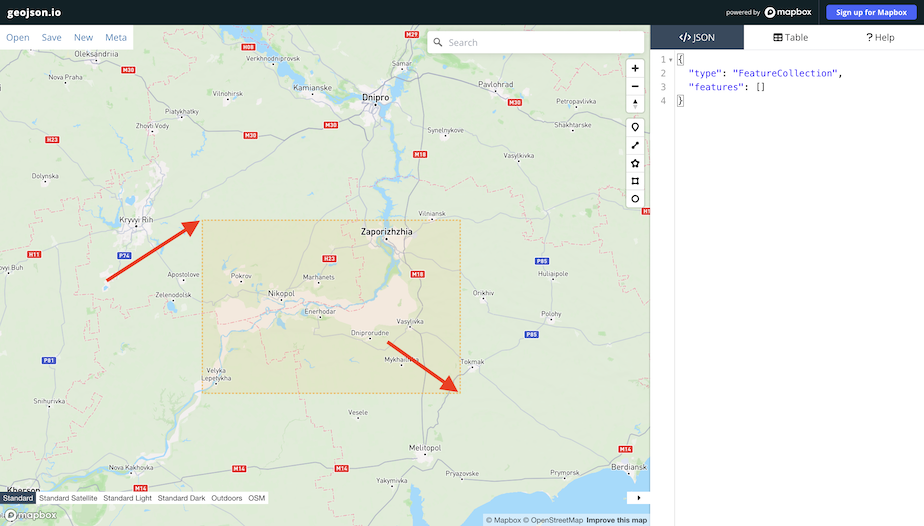

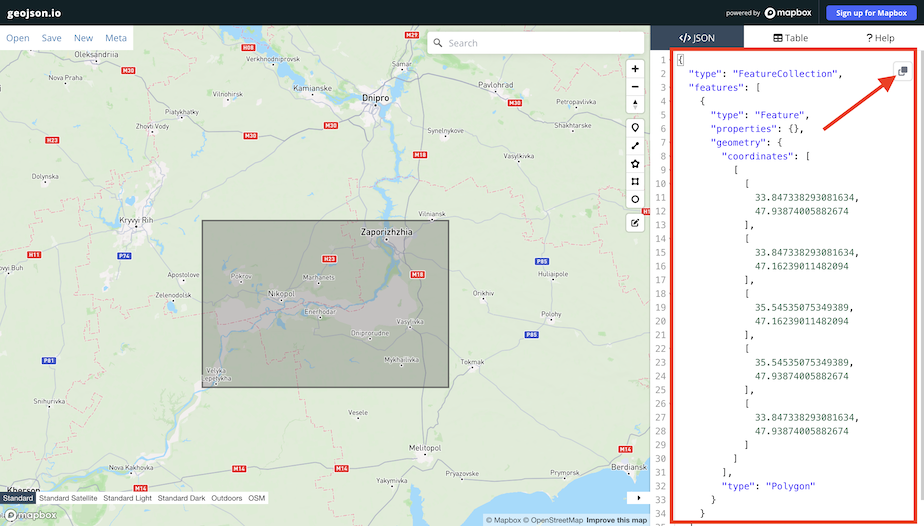

In [62]:
# Area of Interest (AOI) defined as a GeoJSON FeatureCollection.
# Coordinates are provided in WGS84 (longitude, latitude) format.
# The polygon represents the spatial extent used for all subsequent
# filtering, compositing, and clipping operations.
aoi_geojson = {
  "type": "FeatureCollection",
  "features": [
    {
      "type": "Feature",
      "properties": {},
      "geometry": {
        "coordinates": [
          [
            [
              30.1958658411651,
              49.22942623971471
            ],
            [
              30.1958658411651,
              47.63105066457143
            ],
            [
              33.7542653900735,
              47.63105066457143
            ],
            [
              33.7542653900735,
              49.22942623971471
            ],
            [
              30.1958658411651,
              49.22942623971471
            ]
          ]
        ],
        "type": "Polygon"
      }
    }
  ]
}

## 1b. Google Earth project setup

Google requires you to use cloud project to be able to use Earth Engine. Project setup is completely free and will take 2 minutes.

Steps:
1. Register Cloud Project in Google Cloud Console: https://console.cloud.google.com/earth-engine/welcome
2. Setup non-comercial project:
- Organization type = Public or private academic institution (including faculty, staff, students)
- Academic institution name = name of your academic institution (e.g. Kyiv Politechnic Institute)
- Will you receive any payments from commercial entities = No
- Your use of Earth Engine = Scientific research
- Research question = Vegetation Health Assessment Using NDVI
- Geographic scope = Global
- Previously published work - No
- Will you use Earth Engine for any of the following = Classroom or education
- Enable Earth Engine API

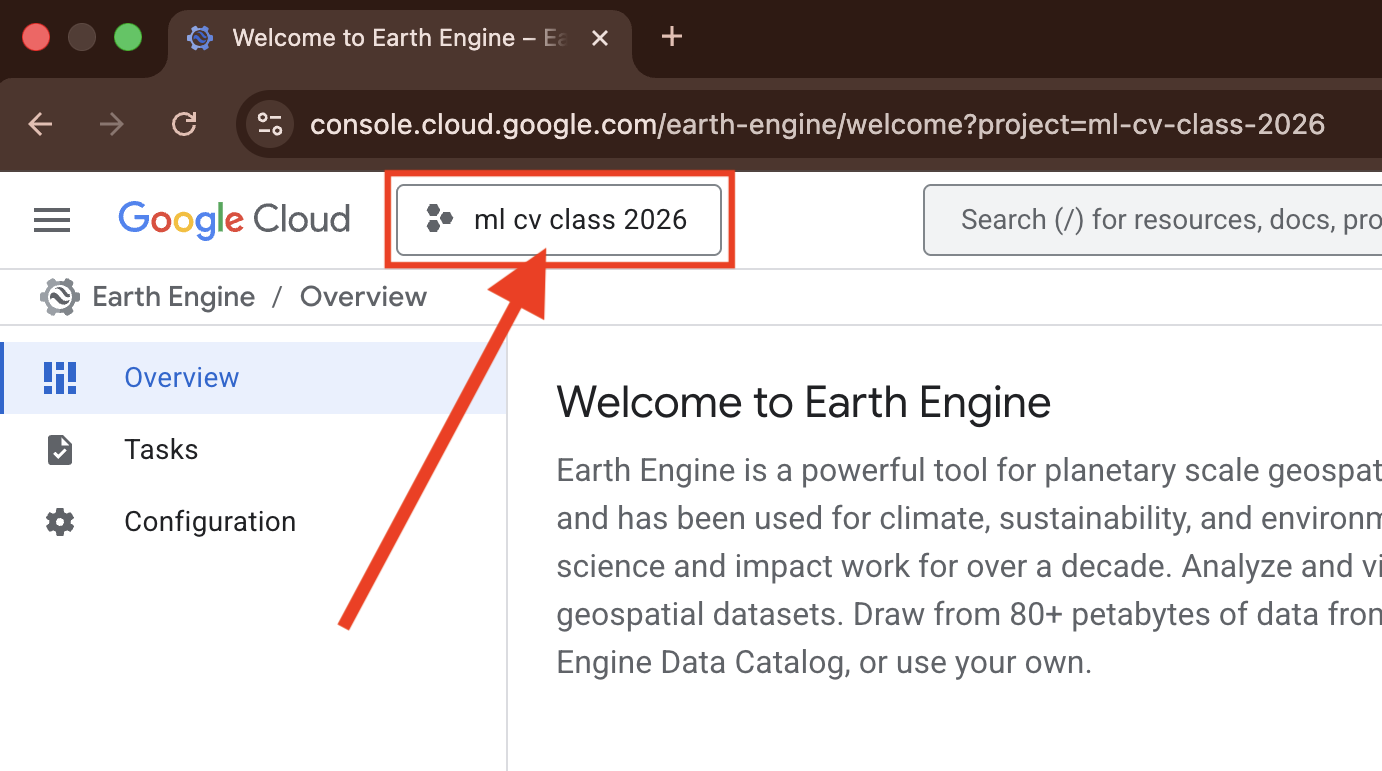

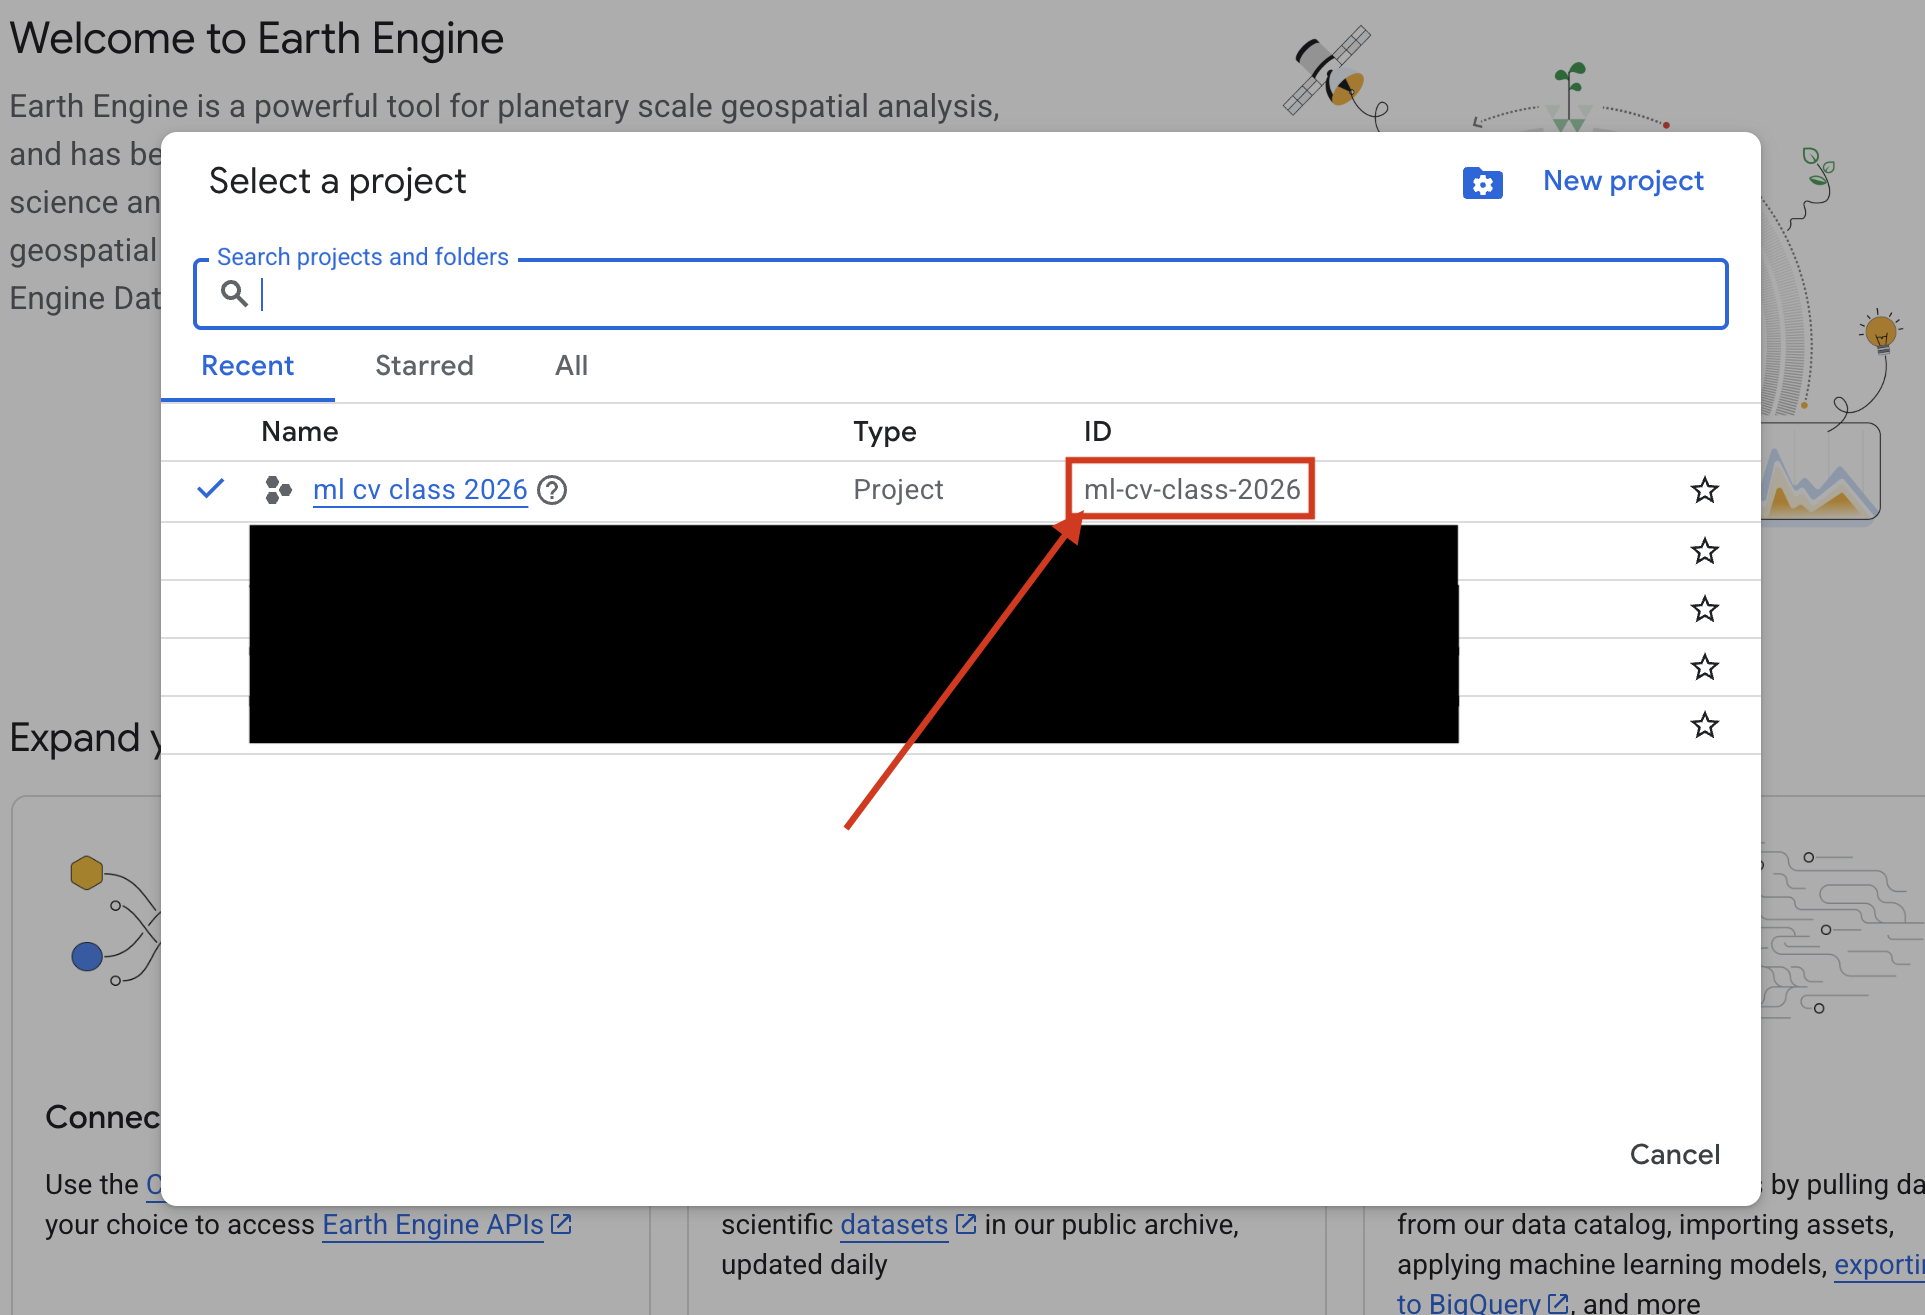

In [63]:
# Google Earth Engine project ID.
# This project must be enabled in Google Cloud Console and linked
# to the authenticated Google account to allow Earth Engine operations.
EE_PROJECT = "ml-cv-class-2026-496115" # set your project ID here

## 1c. Experiment configuraton

In [64]:
# ====================================
# NDVI temporal configuration
# ======================================

# NDVI time window representing the current analysis period.
# This period is used to compute the main NDVI composite.
NDVI_START_DATE = "2024-04-01"
NDVI_END_DATE = "2024-07-01"

# NDVI historical baseline period used for comparison.
# Typically represents a reference year with normal vegetation conditions.
NDVI_HISTORICAL_START_DATE = "2018-04-01"
NDVI_HISTORICAL_END_DATE = "2018-07-01"

# Visualization parameters for NDVI rendering.
# Values outside [min, max] are clipped.
# Color palette represents vegetation health:
# red   -> low NDVI (bare soil / damaged vegetation)
# yellow-> moderate vegetation
# green -> dense and healthy vegetation
NDVI_VISUALIZATION_PARAMS = {
    "min": 0.2,
    "max": 0.9,
    "palette": ["red", "yellow", "green"],
}

# Visualization parameters for NDVI difference (temporal change) maps.
# Negative values indicate vegetation degradation,
# positive values indicate vegetation improvement.
DIFF_VISUALIZATION_PARAMS = {
    "min": -0.4,
    "max": 0.4,
    "palette": ["red", "yellow", "green"],
}

In [65]:
# Step 1: Authenticate the current user with Google Earth Engine.
# This will open a browser window and request Google account authorization.
# Authentication is required only once per environment/session.
ee.Authenticate()

# Step 2: Initialize the Earth Engine Python API.
# The project ID is taken from the global configuration to avoid hardcoding.
# If the project is incorrect or missing permissions, all EE operations will fail.
ee.Initialize(project=EE_PROJECT)

# The AOI is loaded from a GeoJSON structure.
# We explicitly take the first feature, assuming the GeoJSON contains
# a single polygon that defines the area of interest.
# The coordinates are then converted into an Earth Engine Geometry object,
# which can be used for spatial filtering and clipping.
aoi = ee.Geometry.Polygon(
    aoi_geojson["features"][0]["geometry"]["coordinates"]
)

# 2. Utility functions

In [66]:
def build_map(layers):
    """
    Builds an interactive Folium map and fits it to the Area of Interest (AOI).

    Parameters:
        layers (list): A list of Folium map layers to be added to the map.

    Returns:
        folium.Map: An interactive map centered and fitted to the AOI.
    """

    # Step 1: Initialize a base Folium map.
    # The map is created without an explicit center; it will be fitted
    # to the AOI bounds in a later step.
    map = folium.Map(
        zoom_start=11,
        width=800,
        height=600
    )

    # Step 2: Extract polygon coordinates from the AOI GeoJSON.
    # We assume a single Feature with a Polygon geometry.
    # GeoJSON stores coordinates in (longitude, latitude) order.
    aoi_polygon_coords = aoi_geojson["features"][0]["geometry"]["coordinates"][0]

    # Step 3: Separate latitude and longitude values.
    # This is required to compute the bounding box for the AOI.
    lats = [coord[1] for coord in aoi_polygon_coords]
    lons = [coord[0] for coord in aoi_polygon_coords]

    # Step 4: Fit the map view to the AOI bounding box.
    # The map is automatically centered and zoomed to fully contain the AOI.
    map.fit_bounds([
        [min(lats), min(lons)],
        [max(lats), max(lons)]
    ])

    # Step 5: Add all provided layers to the map.
    # Each layer is expected to be a Folium-compatible layer object.
    for layer in layers:
        layer.add_to(map)

    # Step 6: Add a layer control widget to enable toggling layers on/off.
    folium.LayerControl().add_to(map)

    return map

In [67]:
def create_ee_layer(ee_image_object, vis_params, name):
    """
    Creates a Folium TileLayer from a Google Earth Engine image.

    This function converts an Earth Engine Image into a tile-based
    map layer that can be displayed on a Folium map.

    Parameters:
        ee_image_object (ee.Image): Earth Engine image to be visualized.
        vis_params (dict): Visualization parameters (min, max, palette, etc.).
        name (str): Display name of the layer in the map layer control.

    Returns:
        folium.raster_layers.TileLayer: A Folium-compatible tile layer.
    """

    # Step 1: Generate a map ID dictionary for the Earth Engine image.
    # This step requests a tile URL template from Earth Engine,
    # based on the provided visualization parameters.
    map_id_dict = ee.Image(ee_image_object).getMapId(vis_params)

    # Step 2: Create a Folium TileLayer using the EE tile URL.
    # The layer is added as an overlay, allowing it to be toggled on/off.
    return folium.raster_layers.TileLayer(
        tiles=map_id_dict["tile_fetcher"].url_format,
        attr=(
            'Map Data &copy; '
            '<a href="https://earthengine.google.com/">Google Earth Engine</a>'
        ),
        name=name,
        overlay=True,
        control=True
    )

## NDVI from Sentinel-2 Imagery

Normalized Difference Vegetation Index (NDVI) is a remote sensing index that is commonly used to measure the amount of vegetation in an area. NDVI is calculated from the red and near-infrared (NIR) bands of a satellite or aerial image, and it ranges from -1 to 1.

NDVI is calculated by the following formula:

NDVI = (NIR - Red) / (NIR + Red)

Where NIR is the reflectance of the near-infrared band and Red is the reflectance of the red band.

When NDVI value is close to 1, it indicates that the area is covered by healthy vegetation. NDVI values between 0 and 0.2 indicate barren or sparse vegetation, while NDVI values between 0.2 and 0.5 indicate dry vegetation. NDVI values between 0.5 and 0.8 indicate healthy vegetation and NDVI values above 0.8 indicate dense vegetation.

NDVI can be used to monitor crop growth, detect drought, map land cover, and map vegetation health. NDVI is a widely used index in agriculture, and it is a good indicator of plant health, biomass, and leaf area index. NDVI is also used to monitor land use changes, detect deforestation and other changes in land cover.

We will plot NDVI using Sentinel-2 data



In [68]:
# ======================================
# Sentinel-2 preprocessing and NDVI logic
# ======================================

def maskS2sr(image):
    """
    Masks clouds and cirrus contamination in Sentinel-2 Surface Reflectance images.

    Sentinel-2 SR products include a QA60 band with bitwise cloud information.
    This function removes pixels flagged as cloudy or cirrus-affected and
    rescales reflectance values to the [0, 1] range.
    """

    # Step 1: Select the QA60 quality assurance band.
    # This band encodes cloud and cirrus information using bit flags.
    qa = image.select("QA60")

    # Step 2: Define bit masks for cloud detection using the QA60 band.
    # The QA60 band is a 16-bit integer where each bit represents a specific quality flag.
    # In Sentinel-2:
    #   - Bit 10 indicates the presence of opaque clouds
    #   - Bit 11 indicates the presence of cirrus clouds
    #
    # The expression (1 << N) creates a binary number with only the N-th bit set to 1.
    # This allows us to isolate and test a specific bit using bitwise operations.
    cloud_bit_mask = 1 << 10
    cirrus_bit_mask = 1 << 11

    # Step 3: Create a mask where both cloud and cirrus bits are set to zero.
    # Only pixels that are free of clouds and cirrus are retained.
    mask = (
        qa.bitwiseAnd(cloud_bit_mask).eq(0)
        .And(qa.bitwiseAnd(cirrus_bit_mask).eq(0))
    )

    # Step 4: Apply the mask and rescale reflectance values.
    # Sentinel-2 SR data is stored as integers scaled by 10,000.
    return image.updateMask(mask).divide(10000)


def addNDVI(image):
    """
    Computes the Normalized Difference Vegetation Index (NDVI) for a Sentinel-2 image.

    NDVI = (NIR - RED) / (NIR + RED)
    Sentinel-2 bands:
        B8  - Near Infrared (NIR)
        B4  - Red
    """

    # Step 1: Compute NDVI using the normalized difference of NIR and Red bands.
    ndvi = image.normalizedDifference(["B8", "B4"]).rename("NDVI")

    # Step 2: Preserve temporal metadata for downstream temporal analysis.
    return ndvi.copyProperties(image, ["system:time_start"])


def build_ndvi_composite(aoi, start_date, end_date, reducer="median"):
    """
    Builds an NDVI composite image over a specified time range.

    The function:
    - loads Sentinel-2 Surface Reflectance imagery,
    - filters it spatially and temporally,
    - applies cloud masking,
    - computes NDVI for each image,
    - aggregates the collection into a single NDVI composite.

    Parameters:
        aoi (ee.Geometry): Area of Interest.
        start_date (str): Start date (YYYY-MM-DD).
        end_date (str): End date (YYYY-MM-DD).
        reducer (str): Aggregation method.
            - 'median'       : robust seasonal composite (recommended)
            - 'percentile90' : peak vegetation signal
            - 'max'          : sensitive to noise and residual clouds

    Returns:
        ee.Image: Single-band NDVI image clipped to the AOI.
    """

    # Step 1: Load and pre-process Sentinel-2 SR imagery.
    col = (
        ee.ImageCollection("COPERNICUS/S2_SR_HARMONIZED")
        .filterBounds(aoi)
        .filterDate(start_date, end_date)
        .map(maskS2sr)
        .map(addNDVI)
    )

    # Step 2: Aggregate the NDVI time series into a single composite image.
    if reducer == "median":
        # Median NDVI is robust to outliers and residual cloud contamination.
        ndvi = col.median()

    elif reducer == "percentile90":
        # 90th percentile emphasizes peak vegetation conditions.
        ndvi = col.reduce(ee.Reducer.percentile([90])).rename("NDVI")

    elif reducer == "max":
        # Maximum NDVI is not recommended due to sensitivity to noise.
        ndvi = col.max()

    else:
        raise ValueError(
            "Unsupported reducer. Use: 'median', 'percentile90', or 'max'."
        )

    # Step 3: Clip the final NDVI composite to the Area of Interest.
    return ndvi.clip(aoi)


# 3. NDVI Composite Visualization

In this section, we visualize the median NDVI composite for the Area of Interest
over the period from May 15th to August 15th. This composite represents the
overall vegetation condition during the growing season.

The color legend is interpreted as follows:
- **Red (low NDVI):** Bare soil, built-up areas, water, or sparse vegetation
- **Yellow (medium NDVI):** Mixed pixels or stressed vegetation
- **Green (high NDVI):** Healthy and dense vegetation

In [69]:
# ======================================
# NDVI composite generation and visualization
# ======================================

# Step 1: Build an NDVI composite image for the current analysis period.
# The median reducer is used to obtain a robust representation of vegetation
# conditions while minimizing residual cloud effects.
ndvi_image = build_ndvi_composite(
    aoi,
    NDVI_START_DATE,
    NDVI_END_DATE,
    reducer="median"
)

# Step 2: Convert the Earth Engine NDVI image into a Folium-compatible map layer.
# Visualization parameters control value scaling and color mapping.
ndvi_layer = create_ee_layer(
    ndvi_image,
    NDVI_VISUALIZATION_PARAMS,
    "Vegetation (NDVI)"
)

# Step 3: Build and display the interactive map with the NDVI layer.
# The map view is automatically fitted to the Area of Interest.
build_map([ndvi_layer])

# 4. NDVI Temporal Comparison

> Add blockquote



In this section, vegetation conditions observed in 2025 are compared with
earlier Sentinel-2 observations in order to detect temporal changes.

The Sentinel-2 mission was launched in 2015; therefore, no satellite
observations are available prior to this date. For this reason, the historical
reference period is selected from the post-2015 archive.

Temporal comparison is performed using NDVI differencing, defined as:

ΔNDVI = NDVI<sub>current</sub> − NDVI<sub>historical</sub>

Positive ΔNDVI values indicate vegetation improvement, while negative values
indicate vegetation degradation.

In [70]:
# ======================================
# NDVI temporal comparison and change detection
# ======================================

# Step 1: Build an NDVI composite for the historical baseline period.
# This image represents reference vegetation conditions used for comparison.
historical_ndvi_image = build_ndvi_composite(
    aoi,
    NDVI_HISTORICAL_START_DATE,
    NDVI_HISTORICAL_END_DATE,
    reducer="median"
)

# Step 2: Compute NDVI difference (ΔNDVI) between current and historical periods.
# Positive values indicate vegetation improvement,
# negative values indicate vegetation degradation.
delta_ndvi = (
    ndvi_image
    .subtract(historical_ndvi_image)
    .rename("dNDVI")
)

# Step 3: Create visualization layers for current, historical, and difference NDVI.
# Using identical visualization parameters for current and historical NDVI
# ensures a fair visual comparison.
current_ndvi_layer = create_ee_layer(
    ndvi_image,
    NDVI_VISUALIZATION_PARAMS,
    "Current NDVI"
)

historical_ndvi_layer = create_ee_layer(
    historical_ndvi_image,
    NDVI_VISUALIZATION_PARAMS,
    "Historical NDVI"
)

# ΔNDVI layer uses a symmetric color scale centered around zero.
delta_ndvi_layer = create_ee_layer(
    delta_ndvi,
    DIFF_VISUALIZATION_PARAMS,
    "ΔNDVI"
)

# Step 4: Build and display the interactive map with all NDVI layers.
# Layer control allows toggling between temporal states and change maps.
build_map([
    historical_ndvi_layer,
    current_ndvi_layer,
    delta_ndvi_layer
])


In [73]:
print("Task 3: ")

SPRING_START = "2025-04-01"
SPRING_END = "2025-05-31"

SUMMER_START = "2025-08-01"
SUMMER_END = "2025-09-30"

# Build composites for both seasons
spring_ndvi = build_ndvi_composite(aoi, SPRING_START, SPRING_END, reducer="median")
summer_ndvi = build_ndvi_composite(aoi, SUMMER_START, SUMMER_END, reducer="median")

# Calculate the difference
seasonal_delta = summer_ndvi.subtract(spring_ndvi).rename("Seasonal_dNDVI")

# Create map layers
spring_layer = create_ee_layer(spring_ndvi, NDVI_VISUALIZATION_PARAMS, "Spring NDVI")
summer_layer = create_ee_layer(summer_ndvi, NDVI_VISUALIZATION_PARAMS, "Late Summer NDVI")
seasonal_delta_layer = create_ee_layer(seasonal_delta, DIFF_VISUALIZATION_PARAMS, "Seasonal dNDVI")

# Render the map to compare
build_map([spring_layer, summer_layer, seasonal_delta_layer])

Task 3: 


# 5. Reflection Questions

The questions below are intended to help you reflect on the results of the
vegetation analysis and think about their real-world meaning. There are no
strictly correct answers.

1. What changes in vegetation can you observe when comparing the current NDVI
   map with the historical NDVI map?

The "Current NDVI" map distinctly separates the territory into health zones, where the central urban infrastructure and river areas show low vegetation health (NDVI < 0.1), while the surrounding regions show high vegetation health.

In the temporal comparison map (ΔNDVI), the overwhelming dominance of the yellow color indicates that overall vegetation conditions remained largely stable between the 2020 baseline and 2024.

The observable changes are mostly concentrated on the outskirts of the primary area of interest.

2. Are there specific areas where vegetation seems to have improved or degraded?
   What possible real-world reasons could explain these changes?

Yes, the comparison map highlights specific, localized areas of vegetation degradation primarily located on the outskirts of the region, where NDVI values dropped to lower thresholds.

Real-world anthropogenic reasons for this degradation likely include rapid urban expansion, where green zones are replaced by new residential construction.

Other factors include shifts in agricultural dynamics (such as crop rotation or recent harvesting) and the environmental impact of combat operations or fires within the region's forests.

3. Why do you think it is important to compare current vegetation conditions
   with data from previous years instead of analyzing a single map?

Analyzing only a single current map can easily lead to false conclusions; for example, large clusters of low NDVI values might be incorrectly interpreted as severe environmental degradation when they are actually just permanent features like water bodies or established city infrastructure.

Comparing current data against a historical baseline filters out these static features, allowing you to isolate and identify true long-term structural changes to the environment, such as deforestation or new urban development.

It also ensures that you are observing persistent changes rather than temporary seasonal fluctuations, provided you are comparing the exact same timeframe across different years.

4. What limitations or uncertainties do you think might affect the conclusions
   drawn from this analysis?

Environmental Noise: Optical satellite imagery is highly susceptible to interference from clouds, shadows, and varying illumination conditions, which can degrade image quality even when cloud-masking algorithms are applied.

Phenological Shifts: Slight variations in local weather patterns between the historical and current observation periods can alter plant growth stages (phenology), making natural seasonal differences look like permanent degradation or improvement.

Spatial Resolution: While Sentinel-2 is highly effective for large-scale environmental monitoring, its spatial resolution may fail to capture fine-grained, small-scale environmental changes happening at the micro-level.
